# Step 1: NC Parcel Data Sanity Checks

Russell Blessing

## Load libraries

In [ ]:
library(sf)


Linking to GEOS 3.12.0, GDAL 3.11.0, PROJ 9.2.1; sf_use_s2() is TRUE


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

## Point to directories and data

In [ ]:
# Output directory (external to repo; not tracked by git)
out_dir <- "/proj/mhinolab/users/rbless/data/Obstacles_Output"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

out_gpkg <- file.path(out_dir, "parcels_study_area.gpkg")
out_csv  <- file.path(out_dir, "parcels_study_area.csv")

study_area_path <- "/proj/mhinolab/projects/obstacles/NC_huc6_data_union_sf/NC_huc6_data_union_sf.shp"
gpkg_path <- "/proj/mhinolab/users/rbless/data/parcels/NC_Parcels_all.gpkg"
parcels_layer <- "nc_parcels_poly" # update if st_layers() indicates otherwise



cols_keep_attr <- c(
  "cntyfips", "parno", "altparno", "nparno",
  "siteadd", "sunit", "scity", "szip",
  "mailadd", "ownname", "ownfrst", "ownlast",
  "parval", "parusedesc",
  "improvval", "landval", "structyear", "struct", "multistruc", "structno"
)

dup_path <- file.path(out_dir, "dup_counts_studyarea_cntyfips_parno.rds")

out_layer <- "parcels_study_area"


## Study Area

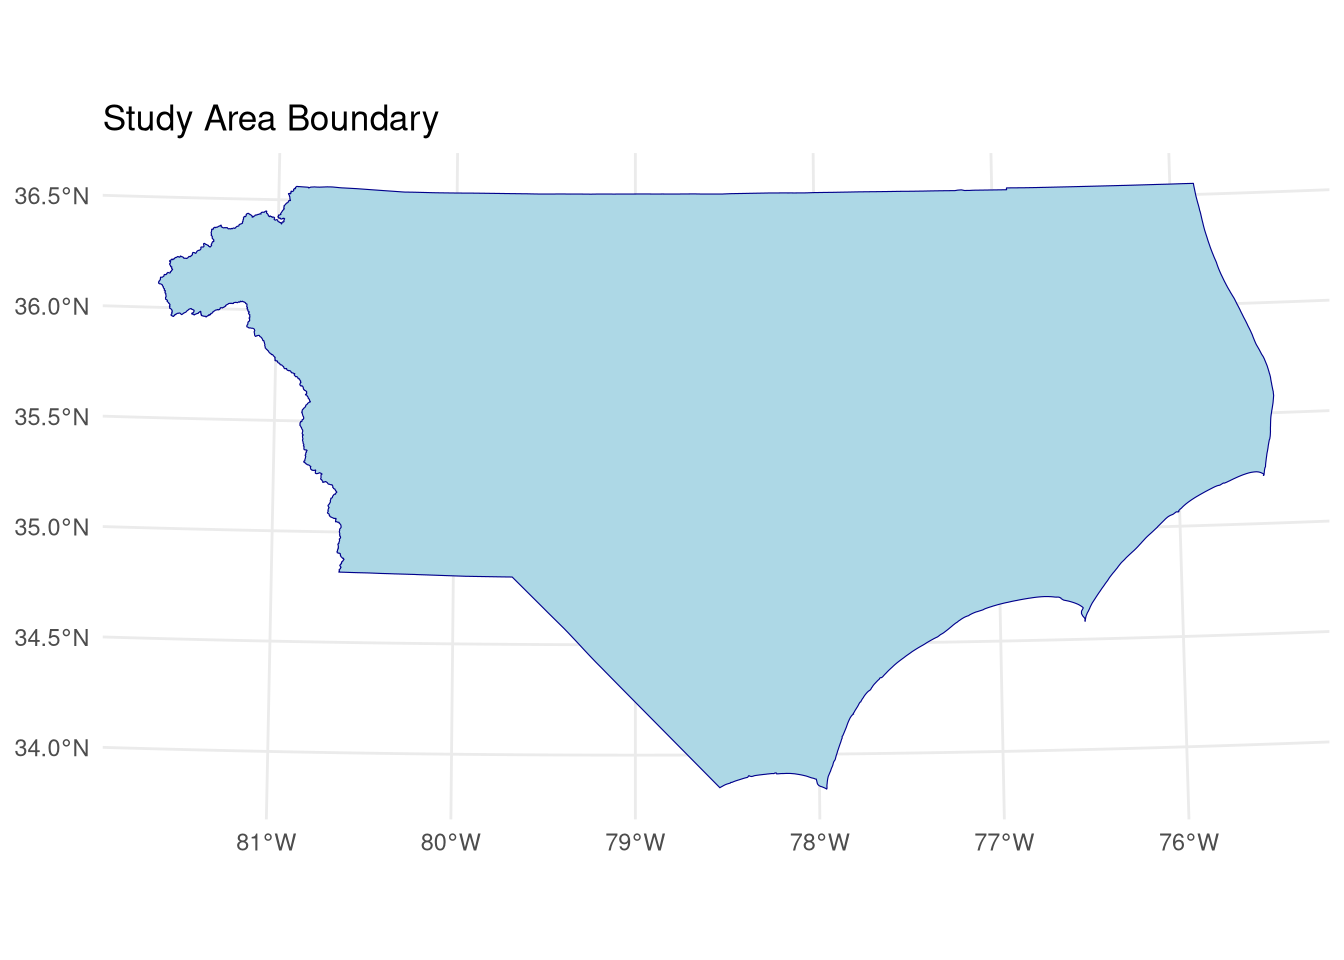

In [ ]:
study_area <- st_read(study_area_path, quiet = TRUE)

study_union <- study_area %>% 
  st_make_valid() %>% 
  st_geometry() %>% 
  st_union() %>% 
  st_sfc(crs = st_crs(study_area)) %>% 
  st_as_sf() %>% 
  st_transform(2264)

study_bbox <- st_bbox(study_union)

ggplot() +
geom_sf(data = study_union, fill = "lightblue", color = "darkblue") +
theme_minimal() +
labs(title = "Study Area Boundary")


## Identify parcel CRS

EPSG = 2264 (NAD83 / North Carolina (ftUS))

In [ ]:
# get_layer_crs <- function(gpkg_path, layer) {
#   sql <- sprintf('SELECT * FROM "%s" LIMIT 0', layer)
#   x0 <- sf::st_read(gpkg_path, query = sql, quiet = TRUE)
#   sf::st_crs(x0)
# }
# 
# parcel_crs <- get_layer_crs(gpkg_path, parcels_layer)
# parcel_crs$epsg   # should be 2264


In [ ]:
x0 <- st_read(gpkg_path,
              query = sprintf('SELECT * FROM "%s" LIMIT 0', parcels_layer),
              quiet = TRUE)
geom_col <- attr(x0, "sf_column")

cols_keep <- c(geom_col, cols_keep_attr)


## Parcels Attributes to Keep

| Variable | Description |
|--------------------------------|-----------------------------------------|
| `cntyfips` | County FIPS code (3-digit) |
| `parno` | Local parcel number |
| `altparno` | Alternate/local parcel number |
| `nparno` | National parcel number (state-county FIPS prefix + local parcel number) |
| `siteadd` | Full site address |
| `sunit` | Site address unit/suite/apartment number |
| `scity` | Site address city |
| `szip` | Site address zip code |
| `mailadd` | Full mailing address |
| `ownname` | Full owner name (primary surface owner) |
| `ownfrst` | Owner first name |
| `ownlast` | Owner last name |
| `parval` | Total parcel value (`improvval` + `landval`), in dollars |
| `parusedesc` | Tax parcel use description (e.g., residential, commercial, agriculture) |
| `improvval` | Value of improvements on the parcel, in dollars |
| `landval` | Value of land on the parcel, in dollars |
| `structyear` | Year built of the primary building |
| `struct` | Structure indicator: Y = yes, N = no, U = unknown |
| `multistruc` | Multiple structures indicator: Y = yes, N = no, U = unknown |
| `structno` | Number of structures on the parcel |

In [ ]:
# Open connection just for this query
con <- dbConnect(RSQLite::SQLite(), gpkg_path)

sql <- sprintf('
  SELECT DISTINCT CAST(cntyfips AS TEXT) AS cntyfips
  FROM "%s"
  WHERE cntyfips IS NOT NULL
  ORDER BY cntyfips
', parcels_layer)

cntys <- dbGetQuery(con, sql)$cntyfips

dbDisconnect(con)

cntys <- cntys[!is.na(cntys) & nzchar(cntys)]


In [ ]:
#if (file.exists(out_gpkg)) file.remove(out_gpkg)

if (!file.exists(out_gpkg)) {

  con <- DBI::dbConnect(RSQLite::SQLite(), gpkg_path)
  on.exit(DBI::dbDisconnect(con), add = TRUE)


  cols_sql <- paste(sprintf('"%s"', cols_keep), collapse = ", ")
  wrote_any <- FALSE
  t0 <- Sys.time()

  for (i in seq_along(cntys)) {
    c <- cntys[[i]]
    if (i %% 5 == 0) {
      message(sprintf("[%d/%d] county=%s elapsed=%.1f min",
                      i, length(cntys), c,
                      as.numeric(difftime(Sys.time(), t0, units="mins"))))
    }

    c_q <- DBI::dbQuoteString(con, c)

    sql <- sprintf(
      'SELECT %s FROM "%s" WHERE CAST(cntyfips AS TEXT) = %s',
      cols_sql, parcels_layer, c_q
    )

    x <- sf::st_read(gpkg_path, query = sql, quiet = TRUE)
    if (nrow(x) == 0) next

    # cheap spatial restrictions
    x <- sf::st_crop(x, study_bbox)
    if (nrow(x) == 0) next

    x_in <- sf::st_filter(x, study_union, .predicate = sf::st_intersects)
    if (nrow(x_in) == 0) next

    sf::st_write(
      x_in,
      out_gpkg,
      layer = out_layer,
      append = wrote_any,
      quiet = TRUE
    )

    wrote_any <- TRUE
    rm(x, x_in); gc()
  }

  if (!wrote_any) stop("No parcels were written—check CRS/study area.")
  message("Wrote: ", out_gpkg)

} else {
  message("Already exists: ", out_gpkg)
}


Already exists: /proj/mhinolab/users/rbless/data/Obstacles_Output/parcels_study_area.gpkg

Clipped gpkg size: 2982.4 MB

In [ ]:
# Add parcel_index as a stable unique row identifier (mirrors Python Step 1)
# Only runs if parcel_index is not already present in the file
existing_cols <- sf::st_layers(out_gpkg)$fields[[1]]

if (!"parcel_index" %in% existing_cols) {
  message("Adding parcel_index to ", out_gpkg)

  nc1_tmp <- sf::st_read(out_gpkg, layer = out_layer, quiet = TRUE) |>
    dplyr::mutate(parcel_index = as.integer(dplyr::row_number()))

  tmp_gpkg <- paste0(out_gpkg, ".tmp.gpkg")
  sf::st_write(nc1_tmp, tmp_gpkg, layer = out_layer, quiet = TRUE)
  file.rename(tmp_gpkg, out_gpkg)

  rm(nc1_tmp); gc()
  message("parcel_index added. New size: ", round(file.size(out_gpkg)/1024^2, 1), " MB")
} else {
  message("parcel_index already present — skipping.")
}


Adding parcel_index to /proj/mhinolab/users/rbless/data/Obstacles_Output/parcels_study_area.gpkg

parcel_index added. New size: 2982.4 MB

In [ ]:
if (!file.exists(dup_path)) {

  if (!file.exists(out_gpkg)) {
    stop("Clipped parcels gpkg not found yet: ", out_gpkg)
  }

  # Read ONLY the fields needed from the clipped layer
  sql <- sprintf('SELECT cntyfips, parno FROM "%s"', out_layer)

  x <- sf::st_read(out_gpkg, query = sql, quiet = TRUE) |>
    sf::st_drop_geometry()

  dup_counts <- x |>
    dplyr::count(cntyfips, parno, name = "n") |>
    dplyr::filter(n > 1) |>
    dplyr::arrange(dplyr::desc(n), cntyfips, parno)

  saveRDS(dup_counts, dup_path)
  message("Saved: ", dup_path)

} else {
  dup_counts <- readRDS(dup_path)
  message("Loaded existing: ", dup_path)
}


Loaded existing: /proj/mhinolab/users/rbless/data/Obstacles_Output/dup_counts_studyarea_cntyfips_parno.rds

## Duplicate Parcels in Study Area

In [ ]:
dup_counts <- readRDS(dup_path) |>
  dplyr::filter(!is.na(parno), nzchar(parno))  # drop null/blank parno

dup_keys <- dup_counts |> 
  dplyr::distinct(cntyfips, parno)

sql <- sprintf('SELECT cntyfips, parno, siteadd, scity, szip FROM "%s"', out_layer)

parcel_addrs <- sf::st_read(out_gpkg, query = sql, quiet = TRUE) |>
  sf::st_drop_geometry() |>
  dplyr::semi_join(dup_keys, by = c("cntyfips", "parno")) |>
  dplyr::slice_head(n = 1, by = c(cntyfips, parno))  # one address row per parcel

dupes_full <- dup_counts |>
  dplyr::left_join(parcel_addrs, by = c("cntyfips", "parno")) |>
  dplyr::mutate(
    full_addr = paste(
      tidyr::replace_na(siteadd, ""),
      tidyr::replace_na(scity, ""),
      "NC",
      tidyr::replace_na(szip, "")
    ),
    maps_url = paste0(
      "https://www.google.com/maps/search/?api=1&query=",
      utils::URLencode(full_addr, reserved = TRUE)
    ),
    maps_link = paste0('<a href="', maps_url, '" target="_blank">Map</a>')
  ) |>
  dplyr::select(cntyfips, parno, n, siteadd, scity, szip, maps_link)

save(dupes_full, file = file.path(out_dir, "duplicate_parcels_study_area.rdata"))


In [ ]:
load(file.path(out_dir, "duplicate_parcels_study_area.rdata"))

datatable(
  dupes_full,
  escape = FALSE,
  filter = "top",
  options = list(pageLength = 10, scrollX = TRUE),
  caption = "Duplicate parcels (by cntyfips + parno) in study area"
)


Warning in instance$preRenderHook(instance): It seems your data is too big for
client-side DataTables. You may consider server-side processing:
https://rstudio.github.io/DT/server.html

In [ ]:

n_parcels <- st_layers(out_gpkg)$features[1]
n_dupes   <- nrow(dupes_full)


The study area contains 4,273,305 total parcels, of which 22,379 contain duplicates.

In [ ]:
dupes_full |>
  dplyr::count(n, name = "num_parcels") |>
  dplyr::arrange(dplyr::desc(n)) |>
  datatable(
    colnames = c("Duplicate Count (n)", "Number of Parcels"),
    caption = "Distribution of duplicate counts",
    options = list(pageLength = 10)
  )
